# GAMBIT — Full Results

Every experiment: the medical study, the resolution sweeps, the evidence-provider
comparison, the synthetic-shortcut ground-truth benchmark, and the corrected paper
re-run — with the qualitative images alongside the numbers.

### A note on nulls, before any number

Most sections report a **`chance`** row. Chance is what a *flat* mask scores — exactly the
target's area fraction. It is the trivial floor, and **it is not a sufficient control**: a
mask can beat chance simply by being small and centred, without localizing anything.

So no headline ratio here is taken against chance. Where a multiple is quoted it is against
the **strongest null**, the largest of:

| null | what it holds fixed | what it tests |
| --- | --- | --- |
| `uniform` | nothing — a flat mask | the trivial floor |
| `center_cell` | a fixed centred square, no model at all | is the dataset's geometry doing the work? |
| `cdea_unique_translated` | the mask's own shape, budget and compactness | does the mask encode *where*, or just *what shape*? |

The difference is not cosmetic. On brain tumour at 14×14, CDEA is **11.3× chance** but only
**1.3× the strongest null** — a ninefold difference in how impressive it sounds.

Run top to bottom. Sections 6 and 7 load or train models and take a few minutes.

In [1]:
from pathlib import Path
import json, glob, os, math, collections, statistics as st
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / 'core').exists() and REPO != REPO.parent:
    REPO = REPO.parent
print('repo:', REPO)

MED   = REPO / 'results' / 'medical_presentation'
SHORT = REPO / 'results' / 'shortcut'
PAPER = REPO / 'results' / 'paper_rerun'

def J(p):
    p = Path(p)
    return json.loads(p.read_text()) if p.exists() else None

def rows_of(d):
    return {r['method']: r for r in (d or {}).get('rows', [])}

NULLS = ['uniform', 'center_cell', 'cdea_unique_translated']
NULL_LABEL = {'uniform': 'chance', 'center_cell': 'centre rect',
              'cdea_unique_translated': 'scrambled'}

def strongest_null(r):
    """Largest of the available nulls. Every quoted multiple uses this, never chance:
    chance is the trivial floor and a small centred mask clears it for free."""
    vals = [r[k]['mean'] for k in NULLS if k in r]
    return max(vals) if vals else float('nan')

BLUE, ORANGE, AQUA, RED, MUTED = '#2a78d6', '#eb6834', '#1baf7a', '#d03b3b', '#898781'
RAMP = ['#86b6ef', '#2a78d6', '#104281']
LAYOUT = dict(template='plotly_white', font=dict(size=13),
              margin=dict(l=60, r=30, t=80, b=60), height=440)

repo: /Users/ssuresh/gambit


## 0. What was run

Enumerated from the result files themselves, so this cannot drift from what is on disk.

In [2]:
inv = []
def add(track, pattern, fn):
    for p in sorted(glob.glob(str(pattern))):
        d = J(p)
        if d: inv.append({'track': track, 'run': Path(p).stem, **fn(d)})

add('1 decomposition', MED/'decomposition'/'*.json',
    lambda d: {'dataset': d['dataset'], 'model': d['model_name'], 'evidence': d['evidence'],
               'grid': f"{d['grid'][0]}x{d['grid'][1]}", 'n': d['num_images']})
add('2 localization', MED/'localization'/'*.json',
    lambda d: {'dataset': d.get('dataset'), 'model': d.get('model_name'), 'evidence': d['evidence'],
               'grid': f"{d['grid'][0]}x{d['grid'][1]}", 'n': d['num_images']})
add('3 resolution', MED/'resolution'/'*.json',
    lambda d: {'dataset': d.get('dataset'), 'model': d.get('model_name'), 'evidence': d['evidence'],
               'grid': f"{d['grid'][0]}x{d['grid'][1]}", 'n': d['num_images']})
add('4 ablation', MED/'ablation'/'*_metrics.json',
    lambda d: {'dataset': d['dataset'], 'model': d['model'], 'evidence': d['evidence'],
               'grid': f"{d['grid_h']}x{d['grid_w']}", 'n': d['num_images']})
add('5 shortcut', SHORT/'sc_*.json',
    lambda d: {'dataset': 'cifar10 control' if d['control'] else 'cifar10 planted',
               'model': d['model'], 'evidence': d['evidence'],
               'grid': f"{d['grid'][0]}x{d['grid'][1]}", 'n': d['rows'][0]['n']})
inv = pd.DataFrame(inv)

seeded = []
for lab, pat in [('6 medical seeds', MED/'seeds'/'ablation_*_metrics.json'),
                 ('7 paper contrastive', PAPER/'contrastive'/'ablation_*_metrics.json')]:
    c = collections.Counter()
    for p in glob.glob(str(pat)):
        d = J(p); c[(d['dataset'], d['evidence'], d['model'])] += 1
    for (ds, ev, m), n in sorted(c.items()):
        seeded.append({'track': lab, 'dataset': ds, 'model': m, 'evidence': ev, 'seeds': n})
c = collections.Counter()
for p in glob.glob(str(PAPER/'shift'/'shift_*_metrics.json')):
    stem = Path(p).stem[len('shift_'):-len('_metrics')]
    base, _ = stem.rsplit('_seed', 1); ds, mode = base.rsplit('_', 1)
    c[(ds, mode)] += 1
for (ds, mode), n in sorted(c.items()):
    seeded.append({'track': '8 paper shift', 'dataset': ds, 'model': 'resnet18',
                   'evidence': f'game={mode}', 'seeds': n})
seeded = pd.DataFrame(seeded)

total = len(inv) + int(seeded['seeds'].sum())
print(f'single runs {len(inv)}  +  seeded runs {int(seeded["seeds"].sum())} '
      f'across {len(seeded)} configs   =   {total} runs')
print('models   :', sorted(set(inv['model'].dropna()) | set(seeded['model'])))
print('evidence :', sorted({e for e in inv['evidence'] if e}))
print('grids    :', sorted(set(inv['grid'].dropna())))
print('plus: centre-prior ladder (annotation only, 2 datasets x grids 7/14/28/56, n=1000 masks)')
display(inv); display(seeded)

single runs 30  +  seeded runs 63 across 21 configs   =   93 runs
models   : ['efficientnet_v2_s', 'resnet18']
evidence : ['gradcam', 'ig', 'occlusion']
grids    : ['14x14', '28x28', '7x7']
plus: centre-prior ladder (annotation only, 2 datasets x grids 7/14/28/56, n=1000 masks)


,track,run,dataset,model,evidence,grid,n
0,1 decomposition,decomp_brain_resnet_gradcam,brain_tumor,resnet18,gradcam,7x7,597
1,1 decomposition,decomp_brain_resnet_ig,brain_tumor,resnet18,ig,7x7,597
2,1 decomposition,decomp_ham10000_effnet_gradcam,ham10000,efficientnet_v2_s,gradcam,7x7,2035
3,1 decomposition,decomp_ham10000_resnet_gradcam,ham10000,resnet18,gradcam,7x7,2035
4,1 decomposition,decomp_ham10000_resnet_ig,ham10000,resnet18,ig,7x7,2035
5,2 localization,localization_null_effnet_gradcam,ham10000,efficientnet_v2_s,gradcam,7x7,2035
6,2 localization,localization_null_resnet_gradcam,ham10000,resnet18,gradcam,7x7,2035
7,3 resolution,res_decomp_brain_g14,brain_tumor,resnet18,ig,14x14,597
8,3 resolution,res_decomp_brain_g28,brain_tumor,resnet18,ig,28x28,597
9,3 resolution,res_decomp_brain_g7,brain_tumor,resnet18,ig,7x7,597


,track,dataset,model,evidence,seeds
0,6 medical seeds,brain_tumor,resnet18,gradcam,3
1,6 medical seeds,brain_tumor,resnet18,ig,3
2,6 medical seeds,ham10000,resnet18,gradcam,3
3,6 medical seeds,ham10000,resnet18,ig,3
4,7 paper contrastive,cifar10,resnet18,gradcam,3
5,7 paper contrastive,cifar10,resnet18,ig,3
6,7 paper contrastive,mnist,resnet18,gradcam,3
7,7 paper contrastive,mnist,resnet18,ig,3
8,7 paper contrastive,pets,resnet18,gradcam,3
9,7 paper contrastive,pets,resnet18,ig,3


## 1. Separation and the mask budget

Three methods on the same images — raw attribution, naive subtraction
(`relu(E_k − mean E_other)`), and CDEA's optimized allocation.

**Read this with a caveat.** `overlap`, `suff` and the budget are all terms in the loss:

```
loss = −(λ_suff·suff + λ_margin·margin) + λ_overlap·overlap + λ_sparse·sparse + λ_mass·mass_dev
```

so "CDEA reduces overlap" is partly "the optimizer optimized its objective". The naive
baseline gives it some force — it does not optimize overlap and achieves far less — but
this is weaker evidence than sections 2 and 6, which test what the loss never asks for.

In [3]:
specs = [('ham10000','gradcam','ablation_unified_ham10000_gradcam_resnet'),
         ('ham10000','ig','ablation_unified_ham10000_ig'),
         ('brain_tumor','gradcam','ablation_unified_brain_tumor_gradcam'),
         ('brain_tumor','ig','ablation_unified_brain_tumor_ig')]
recs = []
for ds, ev, name in specs:
    d = J(MED/'ablation'/f'{name}_metrics.json')
    if not d: continue
    a = d['aggregates']
    recs.append({'dataset': ds, 'evidence': ev,
                 'overlap raw': a['base_evidence']['overlap'],
                 'overlap naive': a['naive_contrastive']['overlap'],
                 'overlap CDEA': a['optimized']['overlap'],
                 'reduction': 1 - a['optimized']['overlap']/a['base_evidence']['overlap'],
                 'suff raw': a['base_evidence']['suff'], 'suff CDEA': a['optimized']['suff'],
                 'budget ratio': a['optimized']['sparse']/max(a['base_evidence']['sparse'],1e-8)})
df_sep = pd.DataFrame(recs)
display(df_sep.style.format({c:'{:.4f}' for c in df_sep.columns
                             if c not in ('dataset','evidence','reduction')} | {'reduction':'{:.0%}'})
        .background_gradient(subset=['reduction'], cmap='Greens'))
print('Budget ratio ~1.0 means the masks did not simply spend more highlight.')
print('It holds on HAM10000 (1.00, 1.02) but drifts on brain tumour (1.19, 1.16) — so there,')
print('part of the sufficiency gain is BOUGHT rather than relocated.')

,dataset,evidence,overlap raw,overlap naive,overlap CDEA,reduction,suff raw,suff CDEA,budget ratio
0,ham10000,gradcam,0.4468,0.2783,0.0729,84%,0.6716,2.4732,1.0257
1,ham10000,ig,0.4949,0.2974,0.1478,70%,0.6597,2.5035,1.0215
2,brain_tumor,gradcam,0.0670,0.0096,0.0084,88%,-0.0008,0.9702,1.1884
3,brain_tumor,ig,0.3260,0.1912,0.0414,87%,-0.1071,1.0477,1.1614


Budget ratio ~1.0 means the masks did not simply spend more highlight.
It holds on HAM10000 (1.00, 1.02) but drifts on brain tumour (1.19, 1.16) — so there,
part of the sufficiency gain is BOUGHT rather than relocated.


In [4]:
fig = go.Figure()
xs = [f"{r['dataset']}<br>{r['evidence']}" for _, r in df_sep.iterrows()]
for col, lab, colr in [('overlap raw','raw evidence',RAMP[0]),
                       ('overlap naive','naive subtraction',RAMP[1]),
                       ('overlap CDEA','CDEA allocation',RAMP[2])]:
    fig.add_bar(name=lab, x=xs, y=df_sep[col], marker_color=colr,
                text=[f'{v:.3f}' for v in df_sep[col]], textposition='outside')
fig.update_layout(title='Competing classes stop sharing evidence<br>'
                        '<sub>mask overlap, lower is better — the naive baseline is what stops this being tautological</sub>',
                  barmode='group', yaxis_title='overlap', **LAYOUT)
fig.show()

### Across three seeds

In [5]:
recs = []
for ds in ('ham10000','brain_tumor'):
    for ev in ('gradcam','ig'):
        per = collections.defaultdict(list)
        for p in sorted(glob.glob(str(MED/'seeds'/f'ablation_{ds}_{ev}_seed*_metrics.json'))):
            d = J(p)
            for m, a in (d or {}).get('aggregates', {}).items():
                for k in ('overlap','suff','sparse','margin'):
                    if k in a: per[(m,k)].append(a[k])
        if not per: continue
        f = lambda m,k: (st.mean(per[(m,k)]), st.stdev(per[(m,k)]) if len(per[(m,k)])>1 else 0.0)
        ob,_ = f('base_evidence','overlap'); oo,oos = f('optimized','overlap')
        sb,_ = f('base_evidence','suff');    so,sos = f('optimized','suff')
        recs.append({'dataset': ds, 'evidence': ev, 'seeds': len(per[('optimized','overlap')]),
                     'overlap raw': ob, 'overlap CDEA': oo, 'overlap ±': oos,
                     'suff raw': sb, 'suff CDEA': so, 'suff ±': sos, 'reduction': 1-oo/ob})
df_seed = pd.DataFrame(recs)
display(df_seed.style.format({c:'{:.4f}' for c in df_seed.columns
                              if c not in ('dataset','evidence','seeds','reduction')}
                             | {'reduction':'{:.0%}'}))
print('Overlap std 0.003-0.02 — the separation result is stable across seeds.')
print('Sufficiency std is larger (0.22-0.47), so quote it with the interval.')

,dataset,evidence,seeds,overlap raw,overlap CDEA,overlap ±,suff raw,suff CDEA,suff ±,reduction
0,ham10000,gradcam,3,0.3709,0.0497,0.0066,0.1670,2.1305,0.4411,87%
1,ham10000,ig,3,0.4891,0.1097,0.0204,0.1235,2.1933,0.4649,78%
2,brain_tumor,gradcam,3,0.0610,0.0083,0.0027,0.2433,1.0716,0.2258,86%
3,brain_tumor,ig,3,0.2976,0.0501,0.0043,0.0862,1.1182,0.2168,83%


Overlap std 0.003-0.02 — the separation result is stable across seeds.
Sufficiency std is larger (0.22-0.47), so quote it with the interval.


## 2. The decomposition is real

The load-bearing result, because **none of it is optimized directly**.

* **Keep only `shared`** → candidates should converge toward equally likely.
* **Add `unique_k` back** → the decision should return.
* **Delete `unique_j`** → class *j* should suffer more than its rivals.

The loss never asks the shared mask to be class-neutral, and never asks that removing one
class's evidence should *help* its rivals. Both happen anyway.

In [6]:
runs = [('decomp_ham10000_effnet_gradcam','HAM10000 · EffNetV2-S · Grad-CAM'),
        ('decomp_ham10000_resnet_gradcam','HAM10000 · ResNet-18 · Grad-CAM'),
        ('decomp_ham10000_resnet_ig',     'HAM10000 · ResNet-18 · IG'),
        ('decomp_brain_resnet_gradcam',   'Brain tumour · ResNet-18 · Grad-CAM'),
        ('decomp_brain_resnet_ig',        'Brain tumour · ResNet-18 · IG')]
recs = []
for name, label in runs:
    d = J(MED/'decomposition'/f'{name}.json')
    if not d: continue
    s = d['spread']
    recs.append({'run': label, 'full': s['full']['mean'], 'shared only': s['shared_only']['mean'],
                 'shared+unique': s['shared_plus_unique']['mean'],
                 'retained': s['shared_only']['mean']/s['full']['mean'],
                 'recovered': s['shared_plus_unique']['mean']/s['full']['mean'],
                 'restores top-1': d['restore_top1_rate'],
                 'diag−offdiag': d['deletion_diag_minus_offdiag']['mean'], 'n': d['num_images']})
df_dec = pd.DataFrame(recs)
display(df_dec.style.format({'full':'{:.3f}','shared only':'{:.3f}','shared+unique':'{:.3f}',
                             'retained':'{:.0%}','recovered':'{:.0%}',
                             'restores top-1':'{:.1%}','diag−offdiag':'{:+.3f}'})
        .background_gradient(subset=['retained'], cmap='Blues_r'))
print('Direction is unanimous: 2 datasets x 2 evidence x 2 backbones.')
print('But no configuration is best at BOTH — the cleanest collapse (ResNet, 51% retained)')
print('has the worst recovery (77%), and the best recovery (EffNetV2-S, 102%) has a muddier')
print('shared mask. That tension is real and unexplained.')

,run,full,shared only,shared+unique,retained,recovered,restores top-1,diag−offdiag,n
0,HAM10000 · EffNetV2-S · Grad-CAM,0.921,0.586,0.935,64%,102%,75.7%,-0.337,2035
1,HAM10000 · ResNet-18 · Grad-CAM,0.805,0.412,0.619,51%,77%,71.5%,-0.151,2035
2,HAM10000 · ResNet-18 · IG,0.805,0.420,0.615,52%,76%,67.7%,-0.160,2035
3,Brain tumour · ResNet-18 · Grad-CAM,0.976,0.670,0.838,69%,86%,94.0%,-0.223,597
4,Brain tumour · ResNet-18 · IG,0.976,0.715,0.823,73%,84%,92.6%,-0.312,597


Direction is unanimous: 2 datasets x 2 evidence x 2 backbones.
But no configuration is best at BOTH — the cleanest collapse (ResNet, 51% retained)
has the worst recovery (77%), and the best recovery (EffNetV2-S, 102%) has a muddier
shared mask. That tension is real and unexplained.


In [7]:
fig = go.Figure()
for col, colr in [('full', BLUE), ('shared only', ORANGE), ('shared+unique', AQUA)]:
    fig.add_bar(name=col, x=df_dec['run'], y=df_dec[col], marker_color=colr,
                text=[f'{v:.2f}' for v in df_dec[col]], textposition='outside')
fig.update_layout(title='Keeping only shared evidence collapses the decision<br>'
                        '<sub>top-1 minus top-K probability gap — lower means the candidates look more alike</sub>',
                  barmode='group', yaxis_title='probability gap', **LAYOUT)
fig.update_xaxes(tickangle=-20); fig.show()

In [8]:
d = J(MED/'decomposition'/'decomp_ham10000_effnet_gradcam.json')
mat = np.array(d['deletion_matrix']); K = mat.shape[0]; lim = float(np.abs(mat).max())
fig = go.Figure(go.Heatmap(z=mat, colorscale=[[0,BLUE],[0.5,'#f0efec'],[1,RED]],
    zmid=0, zmin=-lim, zmax=lim,
    x=[f'remove unique {j}' for j in range(K)], y=[f'class {i}' for i in range(K)],
    text=[[f'{v:+.2f}' for v in row] for row in mat], texttemplate='%{text}',
    colorbar=dict(title='Δ logit')))
fig.update_layout(title="Removing a class's unique evidence hurts that class<br>"
                        '<sub>HAM10000 · EfficientNetV2-S · n=2035</sub>', **LAYOUT)
fig.show()
print('random-mask control, same budget:', [round(v,4) for v in d['deletion_random_control']])
print()
print('Two things here. The diagonal is negative (removing j hurts j), and the column below')
print('it is POSITIVE — removing the top class\'s evidence actively HELPS its rivals')
print('(+0.32, +0.21, +0.13, +0.09). Generic corruption cannot do that, and the equal-budget')
print('random control confirms it: deleting random mass does nothing.')

random-mask control, same budget: [0.0126, -0.0024, -0.0025, 0.0029, 0.0023]

Two things here. The diagonal is negative (removing j hurts j), and the column below
it is POSITIVE — removing the top class's evidence actively HELPS its rivals
(+0.32, +0.21, +0.13, +0.09). Generic corruption cannot do that, and the equal-budget
random control confirms it: deleting random mass does nothing.


### 2b. The shared mask was a blanket — and what fixing it costs

Everything above ran with `lambda_shared_sparse=0.0`, and at that setting the shared mask
carries **no penalty at all**: `lambda_sparse` applies only to the unique masks,
`lambda_overlap` only to unique–unique pairs, `lambda_mass` pins unique mass. Its only
brake is the allocator's partition cap, which never binds on average (mean region
occupancy 0.56 against a cap of 1.0).

Measured over 96 HAM10000 val images at 7×7:

| | λ=0 | λ=0.25 |
| --- | --- | --- |
| shared mass (of 49) | 22.56 | **2.76** |
| shared regions above 0.5 | 47.2% | **3.5%** |
| shared: base evidence captured / area | **0.99× chance** | 1.48× chance |
| unique: base evidence captured / area | 3.35× chance | 3.47× chance |

That third row is the whole problem. At λ=0 the shared mask captures base evidence at
*exactly its own area fraction* — it is uncorrelated with the field it is supposed to be
allocating. It is not a mask that found the background; it is a mask that found nothing.
This is the "evidence appearing where there is nothing" visible in the galleries below.

The unique masks were never affected — 3.35× chance either way.

In [9]:
rows = []
for lab, name in [('HAM · EffNet · Grad-CAM','decomp_ham10000_effnet_gradcam'),
                  ('HAM · ResNet-18 · Grad-CAM','decomp_ham10000_resnet_gradcam'),
                  ('HAM · ResNet-18 · IG','decomp_ham10000_resnet_ig'),
                  ('brain · ResNet-18 · Grad-CAM','decomp_brain_resnet_gradcam'),
                  ('brain · ResNet-18 · IG','decomp_brain_resnet_ig')]:
    r = {'config': lab}
    for tag, sub in [('λ=0','decomposition'), ('λ=0.25','decomposition_sharedfix')]:
        d = J(MED/sub/f'{name}.json')
        M = np.array(d['deletion_matrix']); K = M.shape[0]
        off = (M.sum() - np.trace(M)) / (K*K - K)
        r[f'shared-only {tag}'] = d['spread']['shared_only']['mean']
        r[f'+unique {tag}']     = d['spread']['shared_plus_unique']['mean']
        r[f'|diag|/off {tag}']  = abs(np.trace(M)/K) / off if off > 0 else np.nan
    rows.append(r)
df_fix = pd.DataFrame(rows)
display(df_fix.style.format({c: '{:.3f}' for c in df_fix.columns if c != 'config'}))
print('Test A survives everywhere (t = 14-94 on collapse and recovery in all ten runs).')
print()
print('On HAM the shared-only spread RISES ~0.09 once the blanket is gone. Part of the')
print('original collapse was a washed-out image, not a loss of class evidence: keeping a')
print('soft mask over 46% of the frame degrades the input globally. The honest collapse is')
print('0.805 -> 0.508, not 0.805 -> 0.420 — and recovery improves at the same time.')
print()
print('Test B absolute magnitude falls ~25%, but the off-diagonal falls with it, so the')
print('|diagonal|/off-diagonal ratio is flat on brain and IMPROVES on all three HAM configs.')
print('The equal-budget random control stays at ~0 in all ten runs. Specificity is intact.')
print()
print('OPEN: brain tumor compacts identically (7.2x) but its shared mask stays at chance')
print('(0.93x -> 0.86x) and its shared-only spread barely moves. Compactness is necessary,')
print('not sufficient. K=3 vs 5, a near-saturated model, or genuinely shared anatomy the')
print('class-conditioned evidence field does not mark — untested.')

,config,shared-only λ=0,+unique λ=0,|diag|/off λ=0,shared-only λ=0.25,+unique λ=0.25,|diag|/off λ=0.25
0,HAM · EffNet · Grad-CAM,0.586,0.935,4.394,0.680,0.956,4.711
1,HAM · ResNet-18 · Grad-CAM,0.412,0.619,4.634,0.498,0.670,5.915
2,HAM · ResNet-18 · IG,0.420,0.615,4.558,0.508,0.669,6.044
3,brain · ResNet-18 · Grad-CAM,0.670,0.838,1.759,0.635,0.834,1.759
4,brain · ResNet-18 · IG,0.715,0.823,1.858,0.711,0.822,1.830


Test A survives everywhere (t = 14-94 on collapse and recovery in all ten runs).

On HAM the shared-only spread RISES ~0.09 once the blanket is gone. Part of the
original collapse was a washed-out image, not a loss of class evidence: keeping a
soft mask over 46% of the frame degrades the input globally. The honest collapse is
0.805 -> 0.508, not 0.805 -> 0.420 — and recovery improves at the same time.

Test B absolute magnitude falls ~25%, but the off-diagonal falls with it, so the
|diagonal|/off-diagonal ratio is flat on brain and IMPROVES on all three HAM configs.
The equal-budget random control stays at ~0 in all ten runs. Specificity is intact.

OPEN: brain tumor compacts identically (7.2x) but its shared mask stays at chance
(0.93x -> 0.86x) and its shared-only spread barely moves. Compactness is necessary,
not sufficient. K=3 vs 5, a near-saturated model, or genuinely shared anatomy the
class-conditioned evidence field does not mark — untested.


## 3. Localization — and why chance is not enough

`× strongest null` is the honest summary. `× chance` is shown beside it only to demonstrate
how much the trivial floor flatters the result.

In [10]:
def null_row(d, label):
    r = rows_of(d)
    if not r: return None
    sn = strongest_null(r)
    out = {'run': label}
    out.update({NULL_LABEL[k]: r[k]['mean'] for k in NULLS if k in r})
    out.update({'strongest null': sn, 'base evidence': r['base_evidence']['mean'],
                'CDEA shared': r.get('cdea_shared',{}).get('mean', float('nan')),
                'CDEA unique': r['cdea_unique']['mean'],
                '× chance': r['cdea_unique']['mean']/r['uniform']['mean'],
                '× strongest': r['cdea_unique']['mean']/sn, 'n': d['num_images']})
    return out

recs = [x for x in [null_row(J(MED/'localization'/f'{f}.json'), lab) for f, lab in
        [('localization_null_effnet_gradcam','HAM10000 · EffNetV2-S'),
         ('localization_null_resnet_gradcam','HAM10000 · ResNet-18')]] if x]
df_loc = pd.DataFrame(recs)
display(df_loc.style.format({c:'{:.4f}' for c in df_loc.columns
                             if c not in ('run','n','× chance','× strongest')}
                            | {'× chance':'{:.1f}×','× strongest':'{:.1f}×'})
        .background_gradient(subset=['× strongest'], cmap='RdYlGn', vmin=0.5, vmax=1.5))
print('Both rows: 2.3-2.5x chance, but 0.7-0.8x the strongest null — CDEA LOSES to a fixed')
print('centred rectangle on HAM10000. Quoting "2.5x chance" here would be misleading.')
print()
print('The scrambled null is the informative one: 0.69 vs 0.27 means the mask genuinely')
print('encodes WHERE (+0.43, t=52, better on 89% of images). It just cannot beat a rectangle')
print('on a dataset where dermoscopy centres the lesion by acquisition convention.')

,run,chance,centre rect,scrambled,strongest null,base evidence,CDEA shared,CDEA unique,× chance,× strongest,n
0,HAM10000 · EffNetV2-S,0.2779,0.9058,0.2652,0.9058,0.6515,0.2674,0.6929,2.5×,0.8×,2035
1,HAM10000 · ResNet-18,0.2779,0.9058,0.2647,0.9058,0.4922,0.2706,0.6257,2.3×,0.7×,2035


Both rows: 2.3-2.5x chance, but 0.7-0.8x the strongest null — CDEA LOSES to a fixed
centred rectangle on HAM10000. Quoting "2.5x chance" here would be misleading.

The scrambled null is the informative one: 0.69 vs 0.27 means the mask genuinely
encodes WHERE (+0.43, t=52, better on 89% of images). It just cannot beat a rectangle
on a dataset where dermoscopy centres the lesion by acquisition convention.


In [11]:
cp = J(MED/'figures'/'center_prior.json')
if cp:
    det = cp['detail']; grids = [7,14,28,56]
    fig = go.Figure()
    for ds, colr, nm in [('ham10000',RED,'HAM10000'), ('brain_tumor',BLUE,'Brain tumour')]:
        fig.add_scatter(x=grids, y=[det[ds]['by_grid'][str(g)]['center_1cell'] for g in grids],
                        mode='lines+markers', name=f'{nm} — centre cell',
                        line=dict(color=colr, width=3))
        fig.add_hline(y=det[ds]['chance_area_fraction'], line=dict(color=colr, dash='dot'))
    fig.update_layout(title='A finer grid strengthens the degenerate baseline<br>'
                            '<sub>fixed centre cell, computed from segmentations alone — no model involved</sub>',
                      xaxis_title='grid', yaxis_title='share of mask mass on target',
                      xaxis=dict(type='log', tickvals=grids,
                                 ticktext=[f'{g}×{g}' for g in grids]), **LAYOUT)
    fig.show()
    for ds, nm in [('ham10000','HAM10000'), ('brain_tumor','Brain tumour')]:
        sd = det[ds]['centroid_std_yx']
        print(f'{nm:<14} centroid spread ±{sd[0]:.3f}, ±{sd[1]:.3f} | '
              f'chance {det[ds]["chance_area_fraction"]:.4f} | '
              f'centre-cell null {det[ds]["by_grid"]["7"]["center_1cell"]:.4f}')
    print('\nHAM10000 lesions are centred by acquisition, so the prior is overwhelming (0.94).')
    print('Brain tumours vary in position — twice the spread — so there it is weak (0.13).')

HAM10000       centroid spread ±0.065, ±0.049 | chance 0.2652 | centre-cell null 0.9398
Brain tumour   centroid spread ±0.100, ±0.114 | chance 0.0166 | centre-cell null 0.1312

HAM10000 lesions are centred by acquisition, so the prior is overwhelming (0.94).
Brain tumours vary in position — twice the spread — so there it is weak (0.13).


## 4. Resolution

Same model, evidence, budget and images — only the grid changes. IG attributes at pixel
level so resolution is free; Grad-CAM's is fixed by the backbone's feature map.

In [12]:
recs = []
for ds, tag, nm in [('brain_tumor','brain','Brain tumour'), ('ham10000','ham','HAM10000')]:
    for g in (7,14,28):
        d = J(MED/'resolution'/f'res_loc_{tag}_g{g}.json'); r = rows_of(d)
        if not r: continue
        sn = strongest_null(r)
        cc = {c['comparison']: c for c in d['paired']}.get('cdea_unique_vs_center_cell', {})
        recs.append({'dataset': nm, 'grid': f'{g}×{g}', 'chance': r['uniform']['mean'],
                     'centre rect': r['center_cell']['mean'],
                     'scrambled': r['cdea_unique_translated']['mean'],
                     'strongest null': sn, 'CDEA': r['cdea_unique']['mean'],
                     '× chance': r['cdea_unique']['mean']/r['uniform']['mean'],
                     '× strongest': r['cdea_unique']['mean']/sn,
                     't vs rect': cc.get('t', float('nan'))})
df_res = pd.DataFrame(recs)
display(df_res.style.format({c:'{:.4f}' for c in ['chance','centre rect','scrambled',
                                                  'strongest null','CDEA']}
                            | {'× chance':'{:.1f}×','× strongest':'{:.1f}×','t vs rect':'{:.2f}'})
        .background_gradient(subset=['× strongest'], cmap='RdYlGn', vmin=0.5, vmax=1.6))
print('Brain tumour REVERSES: 0.7x strongest at 7x7 -> 1.3x at 14x14 -> 1.5x at 28x28.')
print('At 7x7 one cell is 2.04% of frame and the mean tumour is 1.76% — the mask could not')
print('express anything smaller than the thing it was looking for.')
print()
print('Note how differently the columns read: 28x28 is "14.9x chance" but "1.5x strongest".')
print('HAM10000 never exceeds 1.0x strongest at any resolution, and worsens when refined.')

,dataset,grid,chance,centre rect,scrambled,strongest null,CDEA,× chance,× strongest,t vs rect
0,Brain tumour,7×7,0.0176,0.1454,0.0175,0.1454,0.0984,5.6×,0.7×,-5.55
1,Brain tumour,14×14,0.0176,0.1549,0.0179,0.1549,0.1994,11.3×,1.3×,3.28
2,Brain tumour,28×28,0.0176,0.1805,0.0218,0.1805,0.2634,14.9×,1.5×,4.81
3,HAM10000,7×7,0.2742,0.9061,0.2611,0.9061,0.5847,2.1×,0.6×,-23.31
4,HAM10000,14×14,0.2742,0.8979,0.2649,0.8979,0.5755,2.1×,0.6×,-23.67
5,HAM10000,28×28,0.2742,0.9257,0.2761,0.9257,0.4462,1.6×,0.5×,-36.82


Brain tumour REVERSES: 0.7x strongest at 7x7 -> 1.3x at 14x14 -> 1.5x at 28x28.
At 7x7 one cell is 2.04% of frame and the mean tumour is 1.76% — the mask could not
express anything smaller than the thing it was looking for.

Note how differently the columns read: 28x28 is "14.9x chance" but "1.5x strongest".
HAM10000 never exceeds 1.0x strongest at any resolution, and worsens when refined.


In [13]:
fig = go.Figure()
for nm, dash in [('Brain tumour','solid'), ('HAM10000','dash')]:
    sub = df_res[df_res['dataset']==nm]
    if sub.empty: continue
    for col, colr in [('CDEA',BLUE), ('centre rect',RED), ('scrambled',AQUA)]:
        fig.add_scatter(x=sub['grid'], y=sub[col], mode='lines+markers',
                        name=f'{nm} — {col}', line=dict(color=colr, dash=dash, width=3))
fig.update_layout(title='Resolution helps where the target is small, hurts where it is large<br>'
                        '<sub>solid = brain tumour (target 1.8% of frame) · dashed = HAM10000 (27.4%)</sub>',
                  xaxis_title='grid', yaxis_title='share of mask mass on target', **LAYOUT)
fig.show()

### Does the decomposition itself survive a finer grid?

It appears to sharpen — and that reading is wrong. Watch **recovery** alongside collapse.

In [14]:
recs = []
for g in (7,14,28):
    d = J(MED/'resolution'/f'res_decomp_brain_g{g}.json')
    if not d: continue
    s = d['spread']; c = (d.get('paired') or {}).get('collapse_full_vs_shared') or {}
    recs.append({'grid': f'{g}×{g}', 'full': s['full']['mean'],
                 'shared only': s['shared_only']['mean'],
                 'shared+unique': s['shared_plus_unique']['mean'],
                 'retained': s['shared_only']['mean']/s['full']['mean'],
                 'recovered': s['shared_plus_unique']['mean']/s['full']['mean'],
                 'restores top-1': d['restore_top1_rate'],
                 'diag−offdiag': d['deletion_diag_minus_offdiag']['mean'],
                 'collapse t': c.get('t', float('nan'))})
df_rd = pd.DataFrame(recs)
display(df_rd.style.format({'full':'{:.3f}','shared only':'{:.3f}','shared+unique':'{:.3f}',
                            'retained':'{:.0%}','recovered':'{:.0%}','restores top-1':'{:.1%}',
                            'diag−offdiag':'{:+.3f}','collapse t':'{:.1f}'}))
print('The naive read — collapse t goes 22 -> 42 -> 96, so finer is better validated — is WRONG.')
print('Recovery degrades in lockstep (84% -> 60% -> 38%), top-1 restoration falls 92% -> 55%.')
print('If the collapse were semantic, adding unique back should restore the decision at ANY')
print('resolution. Both halves degrading together points at a masking artifact: at 28x28 the')
print('mask is so diffuse that keep(x, m) is mostly baseline, so candidates converge because')
print('the kept image carries little information.')
print()
print('=> The decomposition test is most trustworthy at 7x7. The t=96 does not go on a slide.')

,grid,full,shared only,shared+unique,retained,recovered,restores top-1,diag−offdiag,collapse t
0,7×7,0.976,0.714,0.823,73%,84%,92.1%,-0.314,22.5
1,14×14,0.976,0.410,0.589,42%,60%,79.6%,-0.244,41.7
2,28×28,0.976,0.177,0.367,18%,38%,55.1%,-0.173,96.5


The naive read — collapse t goes 22 -> 42 -> 96, so finer is better validated — is WRONG.
Recovery degrades in lockstep (84% -> 60% -> 38%), top-1 restoration falls 92% -> 55%.
If the collapse were semantic, adding unique back should restore the decision at ANY
resolution. Both halves degrading together points at a masking artifact: at 28x28 the
mask is so diffuse that keep(x, m) is mostly baseline, so candidates converge because
the kept image carries little information.

=> The decomposition test is most trustworthy at 7x7. The t=96 does not go on a slide.


## 5. Evidence providers

Everything above rests on gradient methods, which share failure modes. `occlusion` is
perturbation-based — no gradients, no hooks, any architecture — and it measures evidence
with the *same* intervention the objective optimizes against (`unit_space.remove`).

It also does not silently fail on transformers, where Grad-CAM returns an all-zero field
because its non-negative-activation assumption does not hold for LayerNorm'd tokens.

In [15]:
recs = []
for p in sorted(glob.glob(str(SHORT/'sc_planted_*.json'))):
    d = J(p); r = rows_of(d)
    if not r or d['shortcut_rate'] != 1.0: continue
    sn = strongest_null(r)
    recs.append({'evidence': d['evidence'], 'grid': d['grid'][0],
                 'CDEA': r['cdea_unique']['mean'], 'strongest null': sn,
                 '× strongest': r['cdea_unique']['mean']/sn,
                 'base evidence': r['base_evidence']['mean']})
df_prov = pd.DataFrame(recs)
piv = df_prov.pivot_table(index='grid', columns='evidence', values='× strongest')
display(piv.style.format('{:.1f}×', na_rep='—').background_gradient(cmap='Greens'))
display(df_prov.style.format({'CDEA':'{:.4f}','strongest null':'{:.4f}',
                              'base evidence':'{:.4f}','× strongest':'{:.1f}×'}))
print('All three providers agree, so the result is not an artifact of how attribution is')
print('computed. Grad-CAM appears only at 7x7 — its resolution IS the backbone feature map,')
print('and a finer grid there would be interpolation rather than information.')

evidence,gradcam,ig,occlusion
grid,,,
7,12.0×,12.0×,11.1×
14,—,13.0×,10.7×
28,—,8.5×,6.3×


,evidence,grid,CDEA,strongest null,× strongest,base evidence
0,gradcam,7,0.3568,0.0297,12.0×,0.0897
1,ig,14,0.3617,0.0278,13.0×,0.0649
2,ig,28,0.2086,0.0245,8.5×,0.0666
3,ig,7,0.3562,0.0297,12.0×,0.0582
4,occlusion,14,0.2959,0.0278,10.7×,0.1076
5,occlusion,28,0.1540,0.0245,6.3×,0.0725
6,occlusion,7,0.3280,0.0297,11.1×,0.1252


All three providers agree, so the result is not an artifact of how attribution is
computed. Grad-CAM appears only at 7x7 — its resolution IS the backbone feature map,
and a finer grid there would be interpolation rather than information.


## 6. Synthetic shortcuts — the only ground truth here

Every section above is limited by not knowing what class-unique evidence *should* look
like. So we manufacture it: a patch is planted in one CIFAR-10 class at **randomized
positions**, the model learns it, and "did `unique_k` find it?" has an exact answer.

* Ground truth is per-pixel and genuinely **unique to one class**.
* Position is uniform, so the centre prior cannot be exploited — which is why all three
  nulls collapse onto chance here, and `× strongest` ≈ `× chance` for once.

The **negative control** — an identical model that never saw the patch — separates "found
what the model uses" from "salient things attract attribution".

In [16]:
recs = []
for p in sorted(glob.glob(str(SHORT/'sc_*.json'))):
    d = J(p); r = rows_of(d)
    if not r: continue
    sn = strongest_null(r)
    recs.append({'run': Path(p).stem.replace('sc_',''), 'evidence': d['evidence'],
                 'grid': d['grid'][0], 'train rate': 0.0 if d['control'] else d['shortcut_rate'],
                 'attack success': d['attack_success_rate'],
                 'chance': r['uniform']['mean'], 'centre rect': r['center_cell']['mean'],
                 'scrambled': r['cdea_unique_translated']['mean'], 'strongest null': sn,
                 'CDEA unique': r['cdea_unique']['mean'],
                 'CDEA shared': r.get('cdea_shared',{}).get('mean', float('nan')),
                 '× strongest': r['cdea_unique']['mean']/sn})
df_sc = pd.DataFrame(recs).sort_values(['train rate','grid','evidence'])
display(df_sc.style.format({c:'{:.4f}' for c in ['chance','centre rect','scrambled',
                                                 'strongest null','CDEA unique','CDEA shared']}
                           | {'attack success':'{:.3f}','× strongest':'{:.1f}×','train rate':'{:.2f}'})
        .background_gradient(subset=['× strongest'], cmap='Greens'))
print('Control row: 0.9x strongest null, attack success 0.013 — the model ignores the patch,')
print('and so does the evidence. Planted: 8.5-13.0x. The CDEA unique column is the result;')
print('it needs no assumption about the shared mask.')
print()
print('CAVEAT on the CDEA shared column: these runs used lambda_shared_sparse=0.0, where')
print('the shared mask is unpenalized and inflates to blanket ~46% of the frame at 0.99x')
print('chance on base-evidence capture. A blanket scores near its own area fraction by')
print('construction, so do not read the shared column as a finding here. See section 9a')
print('of docs/MEDICAL_RESULTS.md; the shortcut runs have not been repeated at 0.25.')

,run,evidence,grid,train rate,attack success,chance,centre rect,scrambled,strongest null,CDEA unique,CDEA shared,× strongest
0,control_ig_g28,ig,28,0.00,0.013,0.0204,0.0202,0.0200,0.0204,0.0183,0.0201,0.9×
4,planted_ig_g28_rate0.25,ig,28,0.25,0.322,0.0204,0.0202,0.0213,0.0213,0.0588,0.0116,2.8×
5,planted_ig_g28_rate0.50,ig,28,0.50,0.621,0.0204,0.0202,0.0208,0.0208,0.0940,0.0101,4.5×
1,planted_gradcam_g7,gradcam,7,1.00,0.923,0.0204,0.0297,0.0134,0.0297,0.3568,0.0031,12.0×
6,planted_ig_g7,ig,7,1.00,0.923,0.0204,0.0297,0.0138,0.0297,0.3562,0.0028,12.0×
9,planted_occlusion_g7,occlusion,7,1.00,0.923,0.0204,0.0297,0.0127,0.0297,0.3280,0.0028,11.1×
2,planted_ig_g14,ig,14,1.00,0.923,0.0204,0.0278,0.0160,0.0278,0.3617,0.0037,13.0×
7,planted_occlusion_g14,occlusion,14,1.00,0.923,0.0204,0.0278,0.0175,0.0278,0.2959,0.0035,10.7×
3,planted_ig_g28,ig,28,1.00,0.923,0.0204,0.0202,0.0245,0.0245,0.2086,0.0084,8.5×
8,planted_occlusion_g28,occlusion,28,1.00,0.923,0.0204,0.0202,0.0245,0.0245,0.1540,0.0076,6.3×


Control row: 0.9x strongest null, attack success 0.013 — the model ignores the patch,
and so does the evidence. Planted: 8.5-13.0x. The CDEA unique column is the result;
it needs no assumption about the shared mask.

CAVEAT on the CDEA shared column: these runs used lambda_shared_sparse=0.0, where
the shared mask is unpenalized and inflates to blanket ~46% of the frame at 0.99x
chance on base-evidence capture. A blanket scores near its own area fraction by
construction, so do not read the shared column as a finding here. See section 9a
of docs/MEDICAL_RESULTS.md; the shortcut runs have not been repeated at 0.25.


In [17]:
sub = df_sc[(df_sc['grid']==28) & (df_sc['evidence']=='ig')].sort_values('train rate')
fig = go.Figure()
fig.add_scatter(x=sub['attack success'], y=sub['CDEA unique'], mode='lines+markers+text',
                text=[f"rate {r:.2f}" for r in sub['train rate']], textposition='top left',
                marker=dict(size=13, color=BLUE), line=dict(color=BLUE, width=3), name='CDEA unique')
fig.add_scatter(x=sub['attack success'], y=sub['strongest null'], mode='lines',
                line=dict(color=MUTED, dash='dot'), name='strongest null')
rr = np.corrcoef(sub['attack success'], sub['CDEA unique'])[0,1]
fig.update_layout(title=f'Evidence tracks how much the model relies on the shortcut (r = {rr:.3f})<br>'
                        '<sub>x = share of non-target images flipped to the target class when patched</sub>',
                  xaxis_title='attack success rate (model reliance)',
                  yaxis_title='CDEA unique mass on the patch', **LAYOUT)
fig.show()
print('The property an auditing tool needs: not just detecting THAT a shortcut exists,')
print('but tracking HOW MUCH the model depends on it.')

The property an auditing tool needs: not just detecting THAT a shortcut exists,
but tracking HOW MUCH the model depends on it.


### The images

Same inputs, two models. The outline marks the planted patch. Evidence concentrates on it
only when the model actually uses it.

**A note on overlay colours.** A fixed palette does not work across these datasets: red
reads clearly on a grayscale MRI and almost vanishes against pink dermoscopy skin, and the
planted patch here is magenta, so magenta overlays would be ambiguous. The helper below
picks, per image, whichever high-contrast pair sits furthest from that image's own mean
colour — so the same code produces legible overlays on skin, on brain MRI and on natural
photographs.

In [18]:
import torch
from core.runner import CDEAExplainer
from core.hypotheses import TopMSelector
from core.device import get_device
from core.game_modes import resolve_contrastive_game
from modality.grid_regions import VisionGridUnitSpace
from base_evidence.integrated_gradients_regions import IntegratedGradientsRegionsProvider
from base_evidence.gradcam_regions import GradCAMRegionsProvider
from instantiations.contrastive.objective import ContrastiveObjective
from instantiations.contrastive.allocator import OptimizationAllocator
from scripts.ablation_contrastive import _build_model
from scripts.eval_shortcut import ShortcutDataset, cifar, make_patch, train, regions_to_pixels, TV

SEED, TARGET, GRID = 0, 0, 14
device = get_device(); torch.manual_seed(SEED)
patch = make_patch('solid', 32, torch.Generator().manual_seed(SEED))
CACHE = SHORT/'models'; CACHE.mkdir(parents=True, exist_ok=True)
cfg = resolve_contrastive_game('mixed')

def get_model(tag, rate):
    ck = CACHE/f'nb_{tag}_s{SEED}.pt'
    m = _build_model('resnet18', 10, pretrained=True).to(device)
    if ck.exists():
        m.load_state_dict(torch.load(ck, map_location=device, weights_only=True))
        print(f'loaded cached {tag}'); return m.eval()
    ds = ShortcutDataset(cifar(True, 5000, SEED), TARGET, rate, patch, seed=SEED)
    dl = torch.utils.data.DataLoader(ds, batch_size=32, shuffle=True, num_workers=0)
    print(f'training {tag} (rate {rate}) …')
    m = train(m, dl, 4, 1e-4, device); torch.save(m.state_dict(), ck); return m.eval()

def make_explainer(model, unit_space, gh, gw, provider, lam_shared=0.0):
    # lam_shared defaults to 0.0 so the shortcut cells above reproduce their saved runs
    # exactly. The galleries below pass 0.25 — see section 2b for why.
    obj = ContrastiveObjective(lambda_suff=1.0, lambda_margin=cfg.lambda_margin,
                               lambda_sparse=0.05, lambda_overlap=cfg.lambda_overlap,
                               lambda_mass=2.0, lambda_shared_sparse=lam_shared)
    alloc = OptimizationAllocator(obj, num_steps=50, lr=0.2, use_shared=cfg.use_shared,
                                  lambda_disjoint=cfg.lambda_disjoint,
                                  lambda_partition=cfg.lambda_partition)
    return CDEAExplainer(model=model, unit_space=unit_space, selector=TopMSelector(m=5),
                         base_evidence=provider, allocator=alloc, objective=obj,
                         normalize_evidence=True, device=device)

def unique_of(out, target):
    ids = out.hypotheses.ids; B = ids.shape[0]
    slot = (ids == torch.full((B,), target, device=ids.device).unsqueeze(1)).float().argmax(1)
    ar = torch.arange(B, device=ids.device)
    return out.masks['unique'][ar, slot], out.extras['evidence'][ar, slot]

def nz(a):
    lo, hi = float(a.min()), float(a.max())
    return (a-lo)/(hi-lo) if hi > lo else np.zeros_like(a)

# --- adaptive overlay colours -------------------------------------------------
# Fixed colours fail across these datasets: red is invisible on pink dermoscopy skin,
# and the planted CIFAR patch is magenta. Each candidate pair below is high-contrast
# against its partner AND colourblind-distinguishable; we pick the pair whose closest
# member is furthest from the image's own mean colour.
COLOR_PAIRS = [
    ((1.00, 0.84, 0.00), (0.00, 0.80, 1.00), 'yellow / cyan'),
    ((0.00, 1.00, 0.55), (1.00, 0.35, 0.00), 'green / orange'),
    ((1.00, 0.84, 0.00), (0.60, 0.30, 1.00), 'yellow / violet'),
]

def pick_colors(img):
    """Pick the pair whose nearest member is furthest from the background in HUE.

    Euclidean RGB distance is the wrong criterion: it rated orange as a fine overlay for
    dermoscopy, when orange sits almost on top of skin's own hue (~20 deg) and reads only
    marginally better than the red it replaced. Circular hue distance captures that
    directly. For near-grayscale images (MRI) hue is meaningless, so any saturated pair
    works and we take the default."""
    import colorsys
    mean = np.clip(img.reshape(-1, 3).mean(0), 0, 1)
    bh, bs, _ = colorsys.rgb_to_hsv(*mean)
    if bs < 0.15:
        return COLOR_PAIRS[0]
    def hue_dist(c):
        ch = colorsys.rgb_to_hsv(*c)[0]
        d = abs(ch - bh) % 1.0
        return min(d, 1.0 - d)          # circular, 0..0.5
    return max(COLOR_PAIRS, key=lambda p: min(hue_dist(c) for c in p[:2]))

def split_overlay(img, unique, shared):
    """Colour the unique and shared masks so both stay legible on this image.

    Gamma-compressed towards each mask's strongest mass — shared harder, since it is the
    diffuse one and would otherwise flood the frame."""
    c_uni, c_sha, name = pick_colors(img)
    u = np.clip(unique, 0, 1) ** 1.1
    s = np.clip(shared, 0, 1) ** 2.2
    H, W = u.shape
    ov = np.zeros((H, W, 4))
    for ch in range(3):
        ov[..., ch] = c_uni[ch] * u + c_sha[ch] * s * 0.85
    ov[..., 3] = np.clip(np.maximum(u * 0.95, s * 0.55), 0, 1)
    return ov, c_uni, c_sha, name

planted, control = get_model('planted', 1.0), get_model('control', 0.0)
us = VisionGridUnitSpace(GRID, GRID, baseline='blur')
prov = IntegratedGradientsRegionsProvider(grid_h=GRID, grid_w=GRID, steps=16, baseline='zero')
va = ShortcutDataset(cifar(False, 400, SEED+1), TARGET, 1.0, patch, seed=SEED+1)
idx = [i for i in range(len(va)) if va[i][2].sum() > 0][:5]
xs = torch.stack([va[i][0] for i in idx]).to(device)
pms = torch.stack([va[i][2] for i in idx]).cpu().numpy()
op = make_explainer(planted, us, GRID, GRID, prov).explain(xs)
oc = make_explainer(control, us, GRID, GRID, prov).explain(xs)
up, bp = unique_of(op, TARGET); uc, _ = unique_of(oc, TARGET)
px = lambda m: regions_to_pixels(m, GRID, GRID, TV, TV).detach().cpu().numpy()
up, bp, uc = px(up), px(bp), px(uc)
imgs = xs.permute(0,2,3,1).cpu().numpy()
print('explained', len(idx), 'patched validation images through both models')

/opt/anaconda3/envs/marl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded cached planted
loaded cached control


explained 5 patched validation images through both models


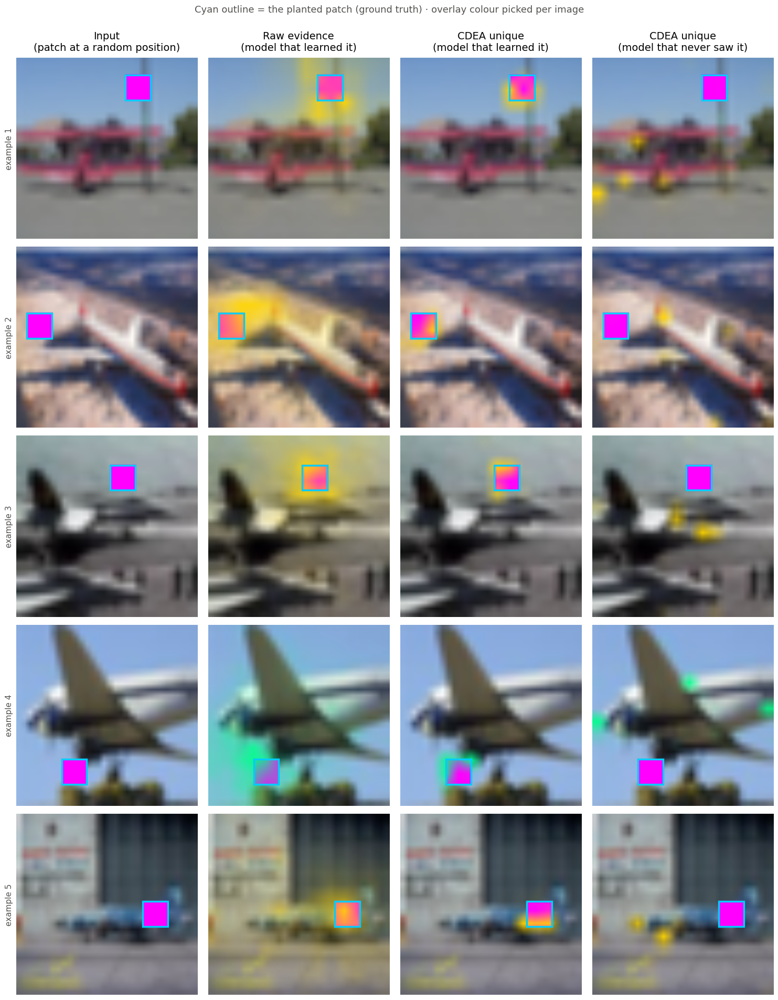

over these 5 images:
  CDEA unique  (planted model)     0.3625   ( 17.8× chance-level patch area)
  raw evidence (planted model)     0.0700   (  3.4× chance-level patch area)
  CDEA unique  (control model)     0.0062   (  0.3× chance-level patch area)
  chance (patch area)              0.0204


In [19]:
titles = ['Input\n(patch at a random position)', 'Raw evidence\n(model that learned it)',
          'CDEA unique\n(model that learned it)', 'CDEA unique\n(model that never saw it)']
n = len(idx)
fig, axes = plt.subplots(n, 4, figsize=(15, 3.8*n), squeeze=False)
for r in range(n):
    ys, xx = np.nonzero(pms[r]); y0,y1,x0,x1 = ys.min(), ys.max(), xx.min(), xx.max()
    c_uni, _, cname = pick_colors(imgs[r])[0], None, pick_colors(imgs[r])[2]
    for c, ov in enumerate([None, bp[r], up[r], uc[r]]):
        ax = axes[r][c]; ax.imshow(imgs[r])
        if ov is not None:
            m = nz(ov) ** 1.1
            col = np.zeros((*m.shape, 4))
            for ch in range(3): col[..., ch] = c_uni[ch]
            col[..., 3] = np.clip(m * 0.92, 0, 1)
            ax.imshow(col)
        # Outline in the *other* member of the pair so it never matches the heat overlay.
        ax.add_patch(plt.Rectangle((x0,y0), x1-x0, y1-y0, fill=False,
                                   edgecolor='#00CCFF', lw=2.5))
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)
        if r == 0: ax.set_title(titles[c], fontsize=14, pad=10)
    axes[r][0].set_ylabel(f'example {r+1}', fontsize=11, color='#52514e')
fig.suptitle('Cyan outline = the planted patch (ground truth) · overlay colour picked per image',
             y=1.001, fontsize=13, color='#52514e')
fig.tight_layout(); plt.show()

def mass_in(mask, tgt):
    m = np.clip(mask,0,None); tot = m.sum()
    return float((m*tgt).sum()/tot) if tot > 0 else 0.0
chance = float(np.mean([p.mean() for p in pms]))
print(f'over these {n} images:')
for nm, arr in [('CDEA unique  (planted model)', up), ('raw evidence (planted model)', bp),
                ('CDEA unique  (control model)', uc)]:
    v = np.mean([mass_in(arr[i], pms[i]) for i in range(n)])
    print(f'  {nm:<32} {v:.4f}   ({v/chance:5.1f}× chance-level patch area)')
print(f'  {"chance (patch area)":<32} {chance:.4f}')

## 7. Example galleries — five per dataset

Five held-out images from every dataset with a trained checkpoint, each showing the same
four panels: the input, raw attribution for the model's top two candidates, and the CDEA
split.

The two rightmost panels are the point. Raw evidence for candidate 1 and candidate 2 tends
to look nearly identical — that is the problem CDEA exists to address — and the split
separates what both rely on from what distinguishes them.

Overlay colours are chosen **per image** (see the helper in §6), because no fixed pair
works across pink dermoscopy skin, grayscale MRI and natural photographs.

In [20]:
from examples.contrastive_explanation import (load_checkpoint, checkpoint_metadata,
                                              MEDICAL_SPLIT_ROOTS, TV_INPUT_SIZE)
from scripts.train_backbone import model_grid_size
from scripts.ablation_contrastive import _get_eval_loader
from torchvision import transforms
from torchvision.datasets import ImageFolder

NAMES = {
    'cifar10': ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'],
    'mnist':   [str(i) for i in range(10)],
    'pets':    ['cat','dog'],
}

def load_any(ckpt, dataset, nclass):
    """Medical checkpoints carry metadata; paper checkpoints are plain state dicts."""
    ckpt = Path(ckpt)
    try:
        model, ds, names, ncls = load_checkpoint(ckpt, device)
        return model, names, ncls, checkpoint_metadata(ckpt)['model_name']
    except Exception:
        m = _build_model('resnet18', nclass, pretrained=False, checkpoint=str(ckpt)).to(device).eval()
        return m, NAMES.get(dataset, [f'class {i}' for i in range(nclass)]), nclass, 'resnet18'

def eval_images(dataset, n, seed=0):
    if dataset in MEDICAL_SPLIT_ROOTS:
        t = transforms.Compose([transforms.Resize((TV_INPUT_SIZE,)*2), transforms.ToTensor()])
        ds = ImageFolder(root=str(MEDICAL_SPLIT_ROOTS[dataset][1]), transform=t)
        order = torch.randperm(len(ds), generator=torch.Generator().manual_seed(seed))[:400].tolist()
        return [(ds[i][0], ds[i][1]) for i in order], len(ds.classes)
    dl, ncls = _get_eval_loader(dataset, 64, REPO/'data', image_size=TV_INPUT_SIZE)
    xs, ys = next(iter(dl))
    return list(zip(xs, ys.tolist())), ncls

def pick_ambiguous(dataset, ckpt, n, prefer_ambiguous=True):
    """Load the model and choose n held-out images, hardest-to-call first.

    Split out of gallery() so the before/after comparison can score exactly the same
    images through two different objectives.
    """
    ckpt = Path(ckpt)
    if not ckpt.exists():
        print(f'{dataset}: checkpoint missing, skipped'); return None
    pool, ncls = eval_images(dataset, n)
    model, names, ncls2, mname = load_any(ckpt, dataset, ncls)
    gh, gw = model_grid_size(mname)
    scored = []
    with torch.no_grad():
        for xi, yi in pool[:200]:
            p = torch.softmax(model(xi.unsqueeze(0).to(device)), -1)[0].cpu()
            tv = p.topk(2)
            scored.append(((tv.values[0]-tv.values[1]).item(), xi, yi, tv))
    scored.sort(key=lambda z: z[0] if prefer_ambiguous else -z[0])
    return model, names, mname, gh, gw, scored[:n]


def provider_for(evidence, gh, gw):
    return (GradCAMRegionsProvider(grid_h=gh, grid_w=gw) if evidence == 'gradcam'
            else IntegratedGradientsRegionsProvider(grid_h=gh, grid_w=gw, steps=16,
                                                    baseline='zero'))


def gallery(dataset, ckpt, n=5, evidence='gradcam', title=None, prefer_ambiguous=True,
            lam_shared=0.25):
    """Five held-out images: input, raw evidence for the top two candidates, CDEA split."""
    got = pick_ambiguous(dataset, ckpt, n, prefer_ambiguous)
    if got is None: return
    model, names, mname, gh, gw, picks = got

    usp = VisionGridUnitSpace(gh, gw, baseline='blur')
    prov = provider_for(evidence, gh, gw)
    ex = make_explainer(model, usp, gh, gw, prov, lam_shared=lam_shared)
    xb = torch.stack([z[1] for z in picks]).to(device)
    out = ex.explain(xb)
    H = W = TV_INPUT_SIZE
    R = lambda m: regions_to_pixels(m, gh, gw, H, W).detach().cpu().numpy()
    ev0, ev1 = R(out.extras['evidence'][:,0]), R(out.extras['evidence'][:,1])
    un0 = R(out.masks['unique'][:,0])
    sh  = R(out.masks['shared']) if 'shared' in out.masks else np.zeros_like(un0)
    ids = out.hypotheses.ids.cpu().numpy()
    nm = lambda j: names[j] if j < len(names) else f'class {j}'

    fig, axes = plt.subplots(n, 4, figsize=(15, 3.8*n), squeeze=False)
    for r in range(n):
        img = picks[r][1].permute(1,2,0).numpy()
        _, _, cname = pick_colors(img)
        ov, c_uni, c_sha, _ = split_overlay(img, nz(un0[r]), nz(sh[r]))
        top = picks[r][3]
        panels = [(None, 'input', f'true: {nm(picks[r][2])}'),
                  (nz(ev0[r]), f'evidence: {nm(ids[r,0])}', f'{top.values[0]:.0%}'),
                  (nz(ev1[r]), f'evidence: {nm(ids[r,1])}', f'{top.values[1]:.0%}'),
                  ('split', 'CDEA split', f'unique={cname.split(" / ")[0]}  shared={cname.split(" / ")[1]}')]
        for c, (o, ti, sb) in enumerate(panels):
            ax = axes[r][c]; ax.imshow(img)
            if isinstance(o, str): ax.imshow(ov)
            elif o is not None:    ax.imshow(o, cmap='inferno', alpha=0.62)
            ax.set_xlabel(sb, fontsize=10, color='#52514e')
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values(): sp.set_visible(False)
            if r == 0: ax.set_title(ti, fontsize=13, pad=8)
    fig.suptitle(title or f'{dataset} — {mname} · {evidence} · {gh}x{gw} grid'
                          f' · lambda_shared_sparse={lam_shared}',
                 y=1.0, fontsize=15)
    fig.tight_layout(); plt.show()


def gallery_compare(dataset, ckpt, n=3, evidence='gradcam'):
    """Same images, same evidence, two objectives: shared unpenalized vs penalized.

    Only the shared mask's L1 weight changes between columns 3 and 4. Everything else —
    model, evidence field, allocator steps, learning rate, every other penalty — is held
    fixed, so any difference visible here is attributable to that one term.
    """
    got = pick_ambiguous(dataset, ckpt, n)
    if got is None: return
    model, names, mname, gh, gw, picks = got
    usp = VisionGridUnitSpace(gh, gw, baseline='blur')
    prov = provider_for(evidence, gh, gw)
    xb = torch.stack([z[1] for z in picks]).to(device)
    H = W = TV_INPUT_SIZE
    R = lambda m: regions_to_pixels(m, gh, gw, H, W).detach().cpu().numpy()

    outs, stats, ev = {}, {}, None
    for lam in (0.0, 0.25):
        o = make_explainer(model, usp, gh, gw, prov, lam_shared=lam).explain(xb)
        s = o.masks['shared'].detach()
        e = o.extras['evidence'].detach(); e = e / e.sum(-1, keepdim=True).clamp_min(1e-8)
        cap = (s.clamp(0,1).unsqueeze(1) * e).sum(-1).mean(1)
        area = s.clamp(0,1).mean(-1)
        outs[lam] = (R(o.masks['unique'][:,0]), R(o.masks['shared']))
        stats[lam] = (s.sum(-1).cpu().numpy(), (cap/area.clamp_min(1e-8)).cpu().numpy())
        # The evidence field does not depend on lambda_shared_sparse; keep one copy.
        if ev is None: ev = R(o.extras['evidence'][:,0])
    nm = lambda j: names[j] if j < len(names) else f'class {j}'
    fig, axes = plt.subplots(n, 4, figsize=(15, 3.8*n), squeeze=False)
    for r in range(n):
        img = picks[r][1].permute(1,2,0).numpy()
        _, _, cname = pick_colors(img)
        cols = [(None, 'input', f'true: {nm(picks[r][2])}'),
                (nz(ev[r]), 'base evidence (top candidate)', 'what the model actually used')]
        for lam in (0.0, 0.25):
            un0, sh = outs[lam]
            ov, _, _, _ = split_overlay(img, nz(un0[r]), nz(sh[r]))
            mass, capx = stats[lam]
            cols.append((ov, f'CDEA split · lambda_shared_sparse={lam}',
                         f'shared mass {mass[r]:.1f}/{gh*gw}  ·  {capx[r]:.2f}x chance'))
        for c, (o, ti, sb) in enumerate(cols):
            ax = axes[r][c]; ax.imshow(img)
            if isinstance(o, np.ndarray) and o.ndim == 3: ax.imshow(o)
            elif o is not None: ax.imshow(o, cmap='inferno', alpha=0.62)
            ax.set_xlabel(sb, fontsize=9.5, color='#52514e')
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values(): sp.set_visible(False)
            if r == 0: ax.set_title(ti, fontsize=12, pad=8)
    fig.suptitle(f'{dataset} — the shared mask before and after it is penalized '
                 f'({cname})', y=1.0, fontsize=15)
    fig.tight_layout(); plt.show()

PAPER_CK = PAPER/'checkpoints'
GALLERIES = [
    ('ham10000',      REPO/'examples'/'out'/'checkpoints'/'ham10000_efficientnet_v2_s.pt', 'gradcam'),
    ('brain_tumor',   REPO/'examples'/'out'/'checkpoints'/'brain_tumor_resnet18.pt',       'gradcam'),
    ('cifar10',       PAPER_CK/'cifar10_resnet18_pt_lp_ep15_lr0.001_seed0.pt',             'gradcam'),
    ('mnist',         PAPER_CK/'mnist_resnet18_pt_lp_ep15_lr0.001_seed0.pt',               'gradcam'),
    ('pets',          PAPER_CK/'pets_resnet18_pt_lp_ep15_lr0.001_seed0.pt',                'gradcam'),
    ('stanford_dogs', PAPER_CK/'stanford_dogs_resnet18_pt_lp_ep15_lr0.001_seed0.pt',       'gradcam'),
]
print('rendering', len(GALLERIES), 'galleries x 5 examples')

rendering 6 galleries x 5 examples


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1396945714950562].


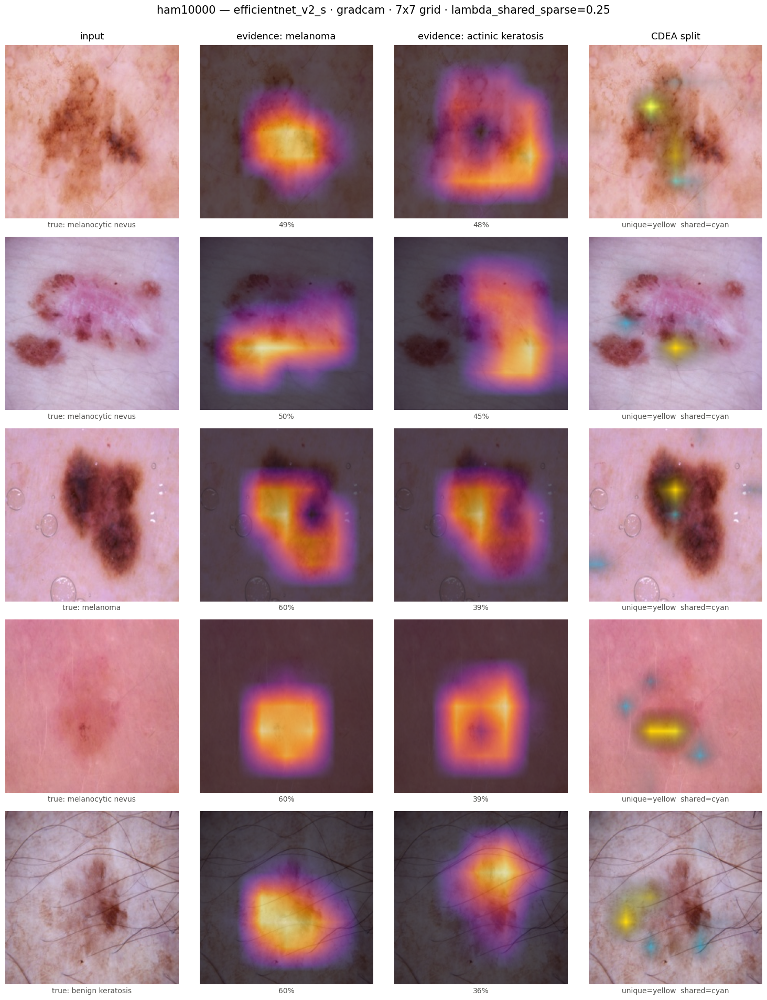

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5136613845825195].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1164472103118896].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1870101690292358].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3866519927978516].


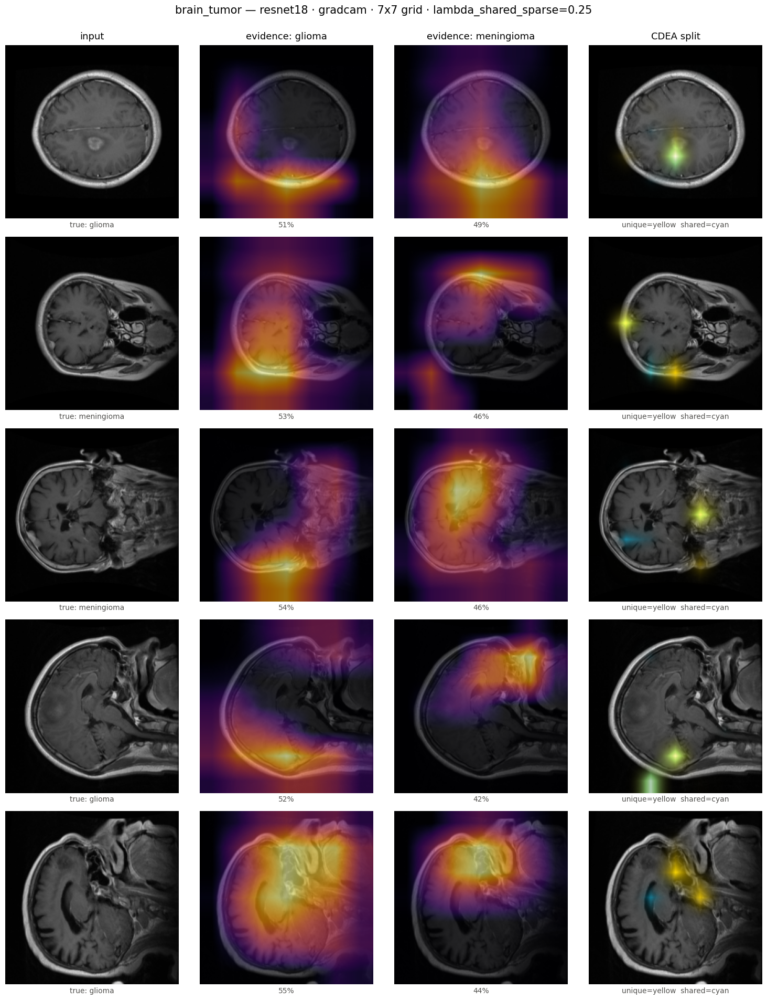

In [21]:
for ds, ck, ev in GALLERIES[:2]:
    gallery(ds, ck, n=5, evidence=ev)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000237226486206].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.008657455444336].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0002027750015259].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0164589881896973].


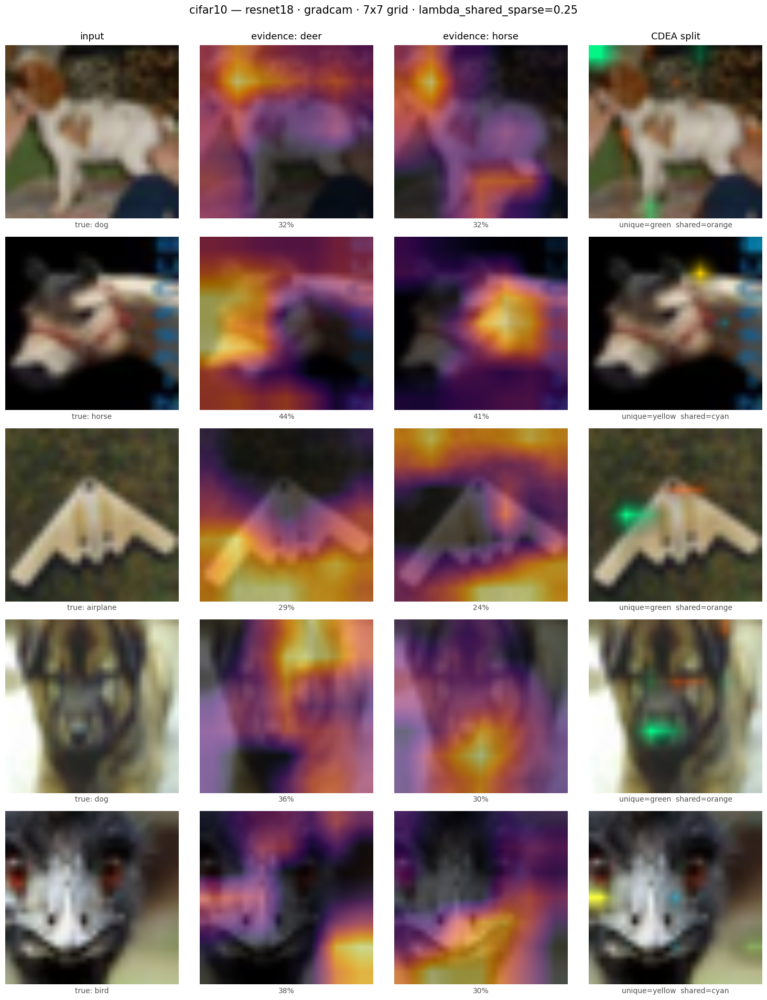

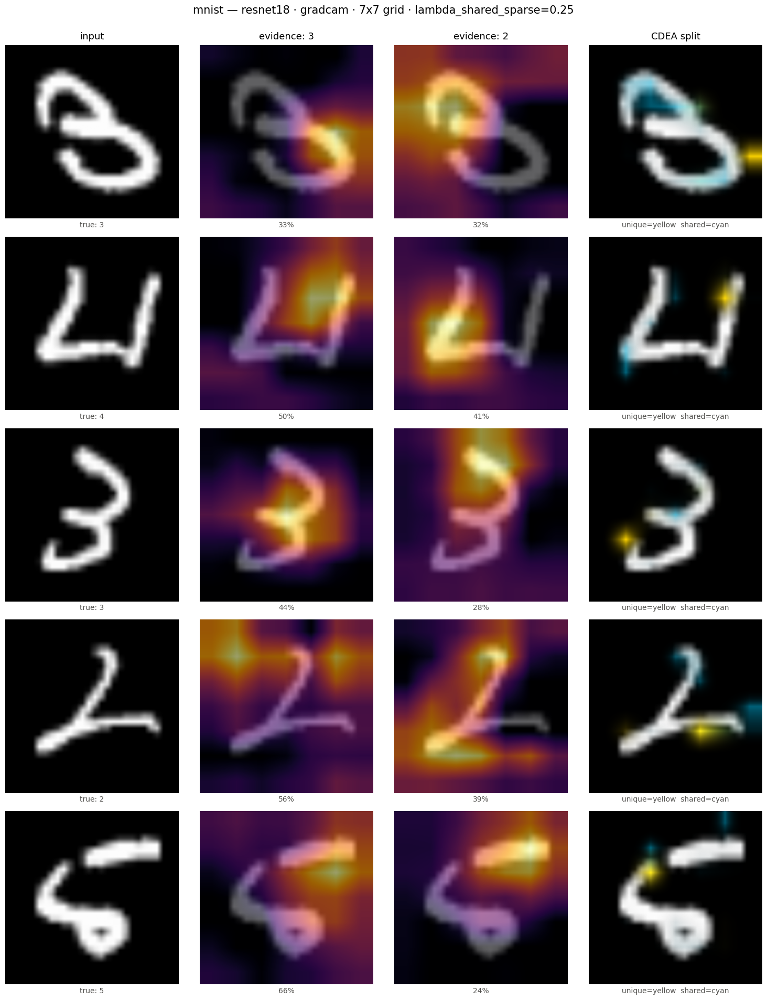

In [22]:
for ds, ck, ev in GALLERIES[2:4]:
    gallery(ds, ck, n=5, evidence=ev)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2975000143051147].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000300407409668].


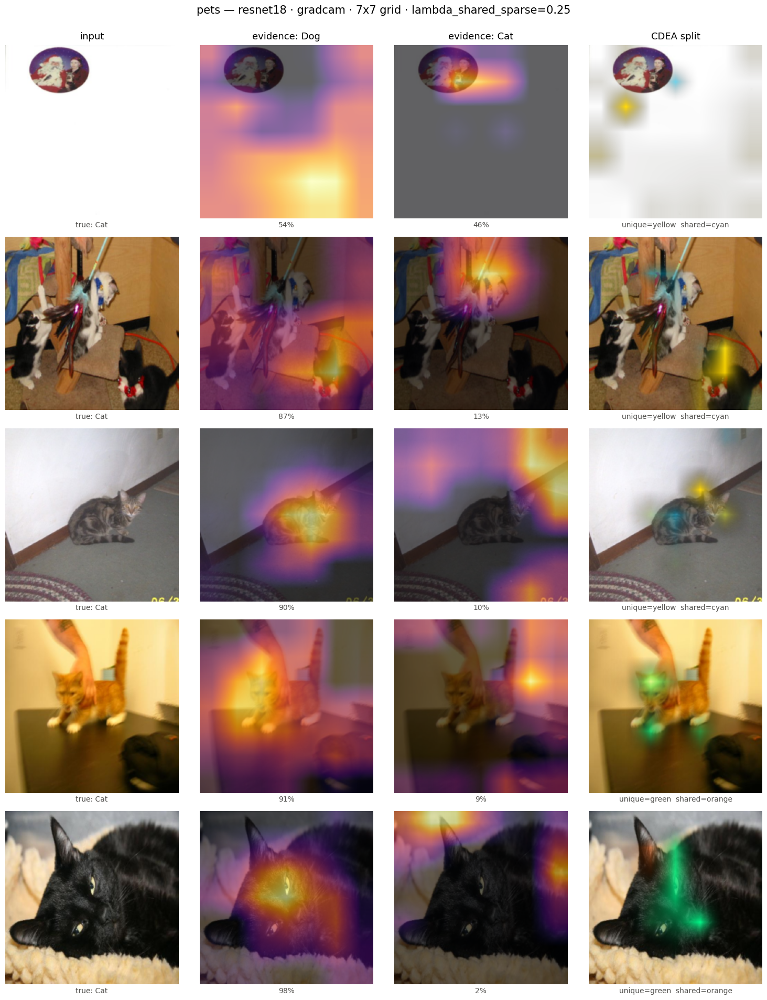

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0008561611175537].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0349522829055786].


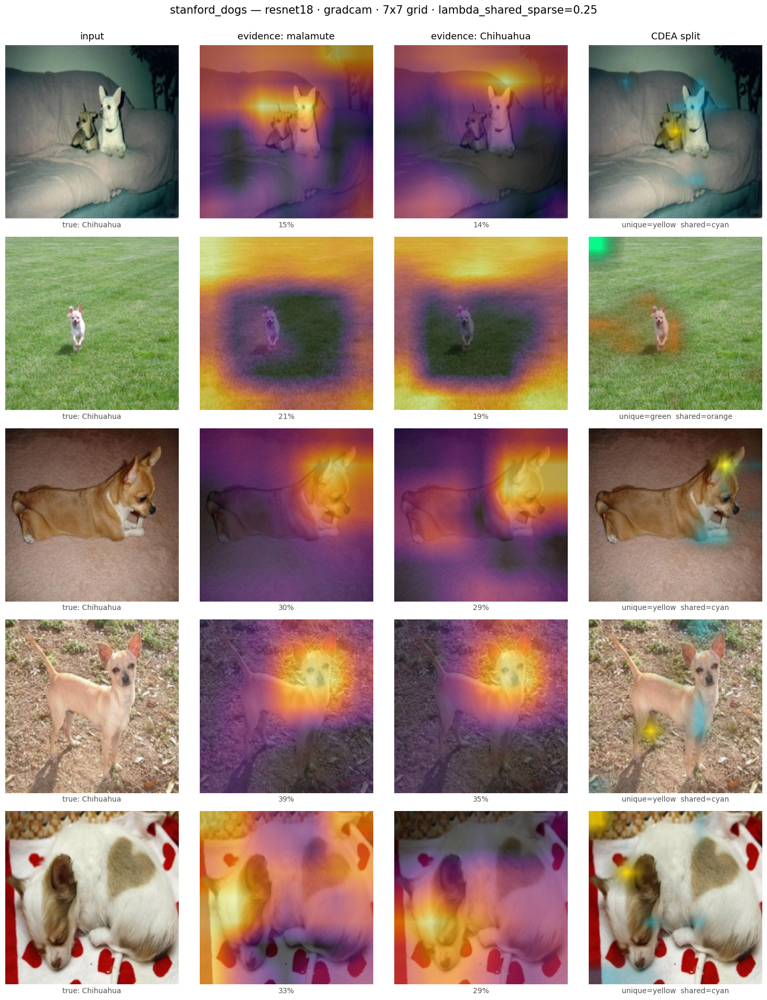


Across all six: the two evidence panels are usually near-duplicates — the model
looks at the same region for both candidates. The split is what separates them.
All six are rendered at lambda_shared_sparse=0.25. The next cell shows why.


In [23]:
for ds, ck, ev in GALLERIES[4:]:
    gallery(ds, ck, n=5, evidence=ev)
print()
print('Across all six: the two evidence panels are usually near-duplicates — the model')
print('looks at the same region for both candidates. The split is what separates them.')
print('All six are rendered at lambda_shared_sparse=0.25. The next cell shows why.')

### The same images, before and after the shared mask is penalized

Only one number changes between the third and fourth columns — the L1 weight on the shared
mask. Model, evidence field, allocator steps, learning rate and every other penalty are
held fixed, so anything that moves is attributable to that term alone.

Each split panel is annotated with its own shared mass and its base-evidence capture
relative to its area. **A value near 1.00× means the shared mask is uncorrelated with the
evidence field it is dividing up** — it is not highlighting the background, it is
highlighting nothing in particular.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1384371519088745].


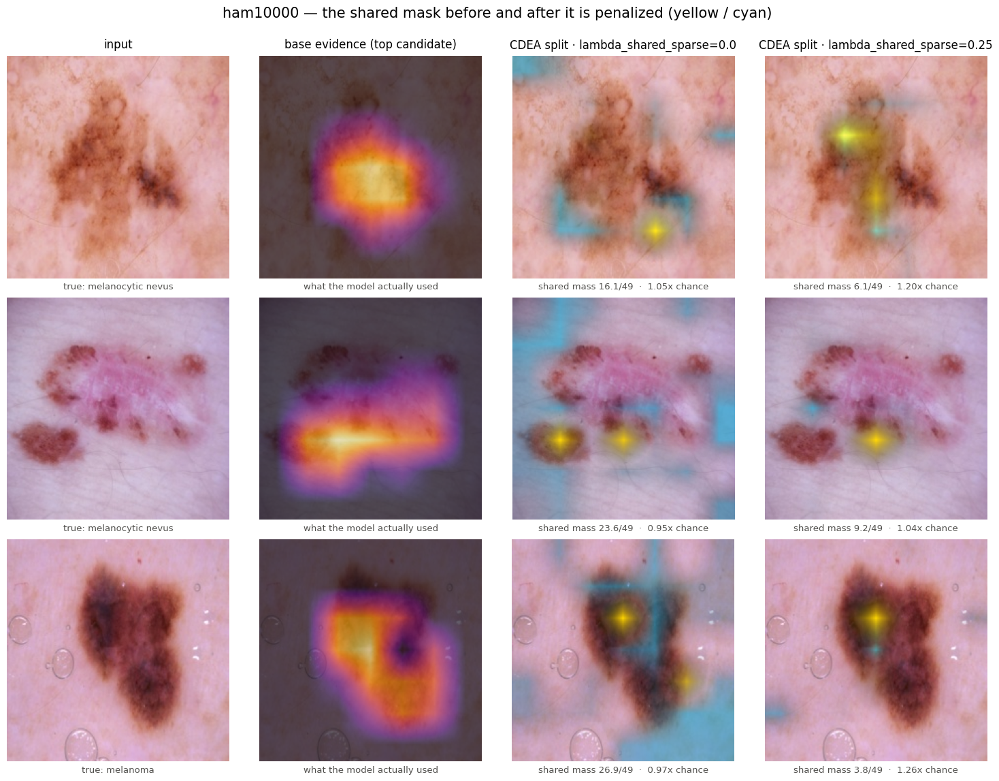

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.5162770748138428].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4761708974838257].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.298126220703125].


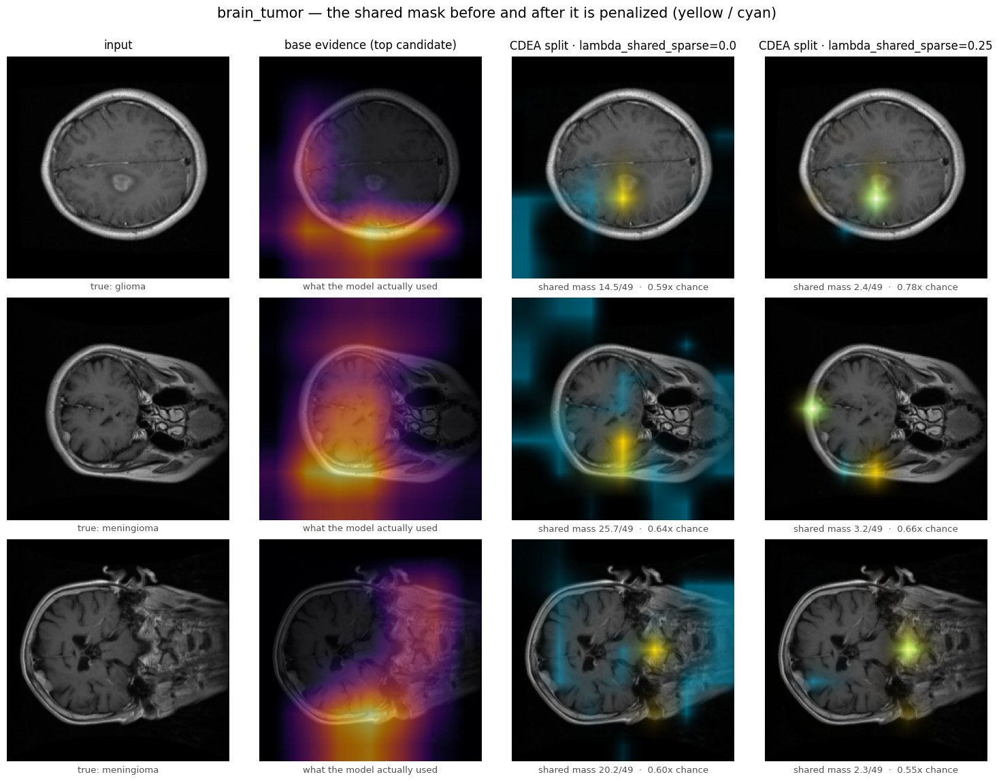


At 0.0 the shared wash spills well past the lesion onto plain skin and covers most
of the frame. That is the artifact behind "evidence appearing where there is
nothing": an unpenalized blanket, not a finding that shared evidence lives on the
background. At 0.25 it contracts onto a small region and the unique mask is
unchanged — the unique masks were never the problem (3.35x chance either way).

Brain tumour is the honest caveat: the mask contracts just as much, but its capture
stays at chance, so compactness alone does not make a shared mask meaningful.
See section 2b and docs/MEDICAL_RESULTS.md 9a.


In [24]:
gallery_compare('ham10000', REPO/'examples'/'out'/'checkpoints'/'ham10000_efficientnet_v2_s.pt',
                n=3, evidence='gradcam')
gallery_compare('brain_tumor', REPO/'examples'/'out'/'checkpoints'/'brain_tumor_resnet18.pt',
                n=3, evidence='gradcam')
print()
print('At 0.0 the shared wash spills well past the lesion onto plain skin and covers most')
print('of the frame. That is the artifact behind "evidence appearing where there is')
print('nothing": an unpenalized blanket, not a finding that shared evidence lives on the')
print('background. At 0.25 it contracts onto a small region and the unique mask is')
print('unchanged — the unique masks were never the problem (3.35x chance either way).')
print()
print('Brain tumour is the honest caveat: the mask contracts just as much, but its capture')
print('stays at chance, so compactness alone does not make a shared mask meaningful.')
print('See section 2b and docs/MEDICAL_RESULTS.md 9a.')

## 8. The correction

`scripts/train_backbone.py` applied ImageNet normalization while every evaluation and
explanation path consumes raw [0,1] tensors. On the same evaluation the CIFAR-10 checkpoint
scored **0.388** mismatched versus **0.809** retrained without normalization.

Everything in `scripts/out/ablation_*`, `scripts/out/shift_*` and the journal report — which
feed both paper drafts — was computed on models at roughly half their true accuracy.
Corrected runs are under `results/paper_rerun/`; nothing was overwritten.

In [25]:
def agg(pattern):
    d = collections.defaultdict(lambda: collections.defaultdict(list))
    for p in glob.glob(str(pattern)):
        j = J(p); k = os.path.basename(p).split('ablation_')[1].rsplit('_seed',1)[0]
        for m, a in (j or {}).get('aggregates', {}).items():
            for metric in ('suff','margin','overlap'):
                if metric in a: d[(k,m)][metric].append(a[metric])
    return d
new = agg(PAPER/'contrastive'/'ablation_*_seed*_metrics.json')
old = agg(REPO/'scripts'/'out'/'ablation_*_seed*_metrics.json')
recs = []
for k in sorted({a for a,_ in new}):
    n_o, n_b = new.get((k,'optimized')), new.get((k,'base_evidence'))
    o_o, o_b = old.get((k,'optimized')), old.get((k,'base_evidence'))
    if not (n_o and n_b and o_o and o_b): continue
    M = lambda d, m: st.mean(d[m])
    recs.append({'config': k,
                 'Δsuff old': M(o_o,'suff')-M(o_b,'suff'), 'Δsuff new': M(n_o,'suff')-M(n_b,'suff'),
                 'Δmargin old': M(o_o,'margin')-M(o_b,'margin'),
                 'Δmargin new': M(n_o,'margin')-M(n_b,'margin')})
df_corr = pd.DataFrame(recs)
display(df_corr.style.format({c:'{:+.3f}' for c in df_corr.columns if c!='config'}))
print('Δ = optimized − base_evidence, i.e. what CDEA actually contributes.')
print('It rises in EVERY configuration. A correctly trained model has sharper logits, so a')
print('diffuse raw-evidence mask leaves a bigger deficit while the optimized mask holds.')
print('The bug was UNDERSTATING the method — on MNIST by more than 10x.')

,config,Δsuff old,Δsuff new,Δmargin old,Δmargin new
0,cifar10_gradcam,+0.183,+0.532,+0.283,+0.765
1,cifar10_ig,+0.206,+0.573,+0.300,+0.817
2,mnist_gradcam,+0.032,+0.656,+0.057,+0.882
3,mnist_ig,+0.027,+0.618,+0.064,+0.798
4,pets_gradcam,+0.212,+1.146,+0.431,+2.237
5,pets_ig,+0.255,+1.122,+0.537,+2.163
6,stanford_dogs_gradcam,+0.386,+1.036,+0.497,+1.174
7,stanford_dogs_ig,+0.389,+0.981,+0.470,+1.151


Δ = optimized − base_evidence, i.e. what CDEA actually contributes.
It rises in EVERY configuration. A correctly trained model has sharper logits, so a
diffuse raw-evidence mask leaves a bigger deficit while the optimized mask holds.
The bug was UNDERSTATING the method — on MNIST by more than 10x.


In [26]:
fig = go.Figure()
fig.add_bar(name='old (buggy)', x=df_corr['config'], y=df_corr['Δmargin old'], marker_color=MUTED)
fig.add_bar(name='corrected',   x=df_corr['config'], y=df_corr['Δmargin new'], marker_color=BLUE)
fig.update_layout(title='What CDEA contributes to the contrastive margin<br>'
                        '<sub>optimized − base evidence, 3 seeds</sub>',
                  barmode='group', yaxis_title='Δ margin', **LAYOUT)
fig.update_xaxes(tickangle=-25); fig.show()

In [27]:
def shift_agg(folder):
    out = collections.defaultdict(list)
    for p in glob.glob(str(Path(folder)/'shift_*_metrics.json')):
        stem = Path(p).stem[len('shift_'):-len('_metrics')]
        parts = stem.rsplit('_seed',1)
        if len(parts) != 2: continue
        j = J(p)
        if j and 'id_ood_gap' in j: out[parts[0]].append(j['id_ood_gap'])
    return out
sn_, so_ = shift_agg(PAPER/'shift'), shift_agg(REPO/'scripts'/'out')
recs = [{'config': c, 'old': st.mean(so_[c]), 'corrected': st.mean(sn_[c]),
         '±': (st.stdev(sn_[c]) if len(sn_[c])>1 else 0.0),
         'ratio': st.mean(sn_[c])/max(abs(st.mean(so_[c])),1e-9)}
        for c in sorted(set(sn_) & set(so_))]
df_shift = pd.DataFrame(recs)
display(df_shift.style.format({'old':'{:.4f}','corrected':'{:.4f}','±':'{:.3f}','ratio':'{:.0f}×'}))
print('id_ood_gap measures how much the model leans on the planted shortcut.')
print('ColoredMNIST uses correlation=0.9 to force that dependency, yet the old numbers (~0.04)')
print('said the model barely used it — about 100x smaller than corrected (~5.34). One config')
print('had a NEGATIVE gap. The shift game was being evaluated on models that did not')
print('measurably have the shortcut it exists to decompose.')
print()
print('Sanity check: id_ood_gap is now near-identical across game modes (5.331/5.341/5.352),')
print('which is correct — it is a property of the model, not of the allocation.')

,config,old,corrected,±,ratio
0,colored_cifar10_competitive,0.4843,3.3828,0.158,7×
1,colored_cifar10_cooperative,0.4052,2.8497,0.065,7×
2,colored_cifar10_mixed,0.4761,3.4432,0.118,7×
3,colored_mnist_competitive,0.0557,5.3310,0.090,96×
4,colored_mnist_cooperative,0.0509,5.3412,0.084,105×
5,colored_mnist_mixed,0.0376,5.3521,0.148,143×
6,texture_mnist_competitive,0.5786,5.4010,0.507,9×
7,texture_mnist_cooperative,-0.2161,3.4170,0.451,16×
8,texture_mnist_mixed,0.5274,5.3915,0.543,10×


id_ood_gap measures how much the model leans on the planted shortcut.
ColoredMNIST uses correlation=0.9 to force that dependency, yet the old numbers (~0.04)
said the model barely used it — about 100x smaller than corrected (~5.34). One config
had a NEGATIVE gap. The shift game was being evaluated on models that did not
measurably have the shortcut it exists to decompose.

Sanity check: id_ood_gap is now near-identical across game modes (5.331/5.341/5.352),
which is correct — it is a property of the model, not of the allocation.


## 9. Summary

**Holds up**

* The shared/unique decomposition has real semantics in all five medical configurations,
  and none of it is a term in the loss. The deletion matrix's positive off-diagonal —
  removing one class's evidence *helps* its rivals — cannot be produced by generic
  corruption, and the equal-budget random control confirms it.
* Against planted ground truth, `unique_k` reaches **8.5–13× the strongest null**, and a
  model that never saw the patch shows nothing (0.9× strongest null, attack success
  0.013). So this is not salience attraction. (The companion `cdea_shared` column is not
  evidence either way — see the caveat in section 6.)
* Evidence tracks model reliance at **r ≈ 0.955** — the property that makes it usable for
  auditing rather than illustration.
* Three independent providers (Grad-CAM, IG, occlusion) agree, so it is not an artifact of
  how attribution is computed.

**Does not**

* Lesion overlap cannot validate a contrastive decomposition: the outline is ground truth
  for *shared* evidence, and on HAM10000 CDEA scores **0.7–0.8× the strongest null** — it
  loses to a fixed rectangle at every resolution. Reporting "2.5× chance" there, as an
  earlier version of this notebook did, is misleading.
* Resolution has no simple rule. An earlier "~13 cells per target" heuristic, inferred from
  the two medical datasets, is **contradicted** by the shortcut benchmark, where 7×7 ties
  for best and 28×28 is worst. Treat it as an observation about those datasets, not a design
  principle.
* The apparent sharpening of the decomposition at fine grids is a masking artifact —
  recovery degrades alongside collapse.
* Overlap, sufficiency and margin are all optimized directly, so section 1 is weaker
  evidence than sections 2 and 6.

**Open**

* Whether the fine-grid degradation is allocator under-convergence (784×5 mask parameters
  against 49×5, at the same 50 steps).
* Re-deriving both paper drafts from `results/paper_rerun/`, and narrowing — not deleting —
  the §8.1 limitation, which survives on Stanford Dogs.